# Exploratory Data Analysis and Visualisation

**Note:** We are working in a specialized environment with specific versions of the imported libraries to address compatibility issues with TensorFlow. The environment and version specifications can be found in the README.

In [1]:
# Standard Libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# Visualization Library
import seaborn as sns

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Custom Module
from implementations.data_to_image import Image 
#our own implementations and functions can be found in the "implementations" folder


In [2]:
# Load the data
train_data = np.load('data/original_data_set/fashion_train.npy')
test_data = np.load('data/original_data_set/fashion_test.npy')

## Data Information


In [3]:
# Display basic information about the data
print("Shape of train_data:", train_data.shape)
print("Shape of test_data:", test_data.shape)

Shape of train_data: (10000, 785)
Shape of test_data: (5000, 785)


The output below shows the dimensions (shape) of the training and testing datasets:

- **`train_data.shape → (10000, 785)`**  
  The training dataset contains **10,000 samples**, where each sample has **785 features**:
  - **784 features** represent pixel values from a flattened 28x28 grayscale image.
  - **1 feature** represents the class label of the image.

- **`test_data.shape → (5000, 785)`**  

### Important Notes:
1. The pixel values are flattened, meaning the original 2D images (28x28) have been converted into 1D arrays of 784 values.
2. The final column in each sample represents the **class label**.

## Displaying One Image from Each Class

The following code displays one image from each of the five available classes (0-4) in the `train_data` dataset. The images are shown alongside their corresponding class labels.

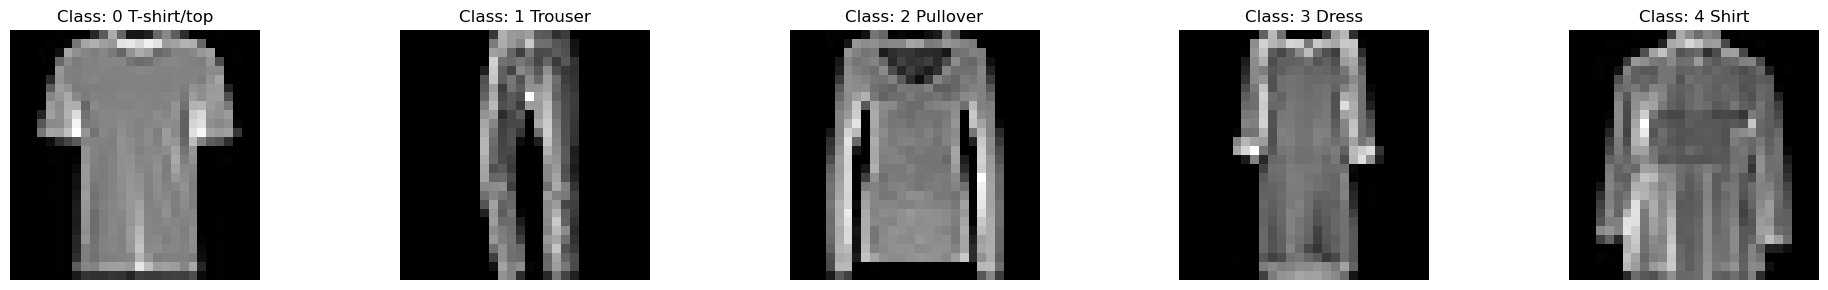

In [4]:
# Assuming train_data contains both the images and labels, and Image handles extracting data correctly.
image_shape = (28, 28)

# Prepare the figure for displaying images
fig, axs = plt.subplots(1, 5, figsize=(20, 3))  # We will show one image for each class (0 to 4)

n = 0

# Loop over each class (0 to 4) and select one image from each class
for class_label in range(5):  # Loop over only the available classes
    # Find the indices of the images that belong to the current class
    class_indices = np.where(train_data[:, -1] == class_label)[0]  
    
    if class_indices.size == 0:  # No images found for this class, skip it
        continue
    
    # Select the first image from the current class
    selected_index = class_indices[0]  # You can use any index here, but we'll pick the first image for simplicity
    
    # Create an Image object to handle the image data for the selected index
    this_image = Image(train_data, selected_index)

    # Display the image
    axs[n].imshow(this_image.image.reshape(image_shape), cmap='gray')
    
    # Use the _tell_class method from the Image class to get the label
    axs[n].set_title(f"{this_image._tell_class()}")
    axs[n].axis('off')  # Turn off axis for clearer visuals
    n += 1

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

## Separating Features and Labels

We separate the features (image data) and labels (class labels) for both the training and testing datasets:

- **Training Data**:
  - **Features (`X_train_full`)**: All columns except the last one (pixel values).
  - **Labels (`y_train_full`)**: The last column (class labels).

And same goes for the test set.

In [24]:
# Separate features and labels
X_train_full, y_train_full = train_data[:, :-1], train_data[:, -1]
X_test, y_test = test_data[:, :-1], test_data[:, -1]

output_folder = 'data/subsets'
os.makedirs(output_folder, exist_ok=True)

# Save the separated features and labels to the 'data/subsets' folder
np.save(os.path.join(output_folder, 'X_train_full.npy'), X_train_full)
np.save(os.path.join(output_folder, 'y_train_full.npy'), y_train_full)
np.save(os.path.join(output_folder, 'X_test.npy'), X_test)
np.save(os.path.join(output_folder, 'y_test.npy'), y_test)

## Dataset Shape Overview

The following shapes represent the features (`X_*`) and labels (`y_*`) for both the training and testing datasets:

- **Training Data**:
  - **Features (`X_train_full`)**: `(10000, 784)` — 10,000 images, each with 784 pixels (28x28 flattened).
  - **Labels (`y_train_full`)**: `(10000,)` — 10,000 labels, each corresponding to an image in `X_train_full`.

- **Testing Data**:
  - **Features (`X_test`)**: `(5000, 784)` — 5,000 images, each with 784 pixels.
  - **Labels (`y_test`)**: `(5000,)` — 5,000 labels, each corresponding to an image in `X_test`.

In [6]:

print("\nShape of X_train_full:", X_train_full.shape)
print("Shape of y_train_full:", y_train_full.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train_full: (10000, 784)
Shape of y_train_full: (10000,)
Shape of X_test: (5000, 784)
Shape of y_test: (5000,)


In [7]:
def separate_image_class(data_point_number):
    combined_array = train_data[data_point_number]  # Use train_data
    array_of_the_image = combined_array[:-1]  # Extract the pixel values
    classification_of_the_image = combined_array[-1]  # Extract the label
    class_of_the_image = tell_class(classification_of_the_image)
    return array_of_the_image, class_of_the_image

Counter({0: 2033, 4: 2014, 3: 2005, 2: 2001, 1: 1947})


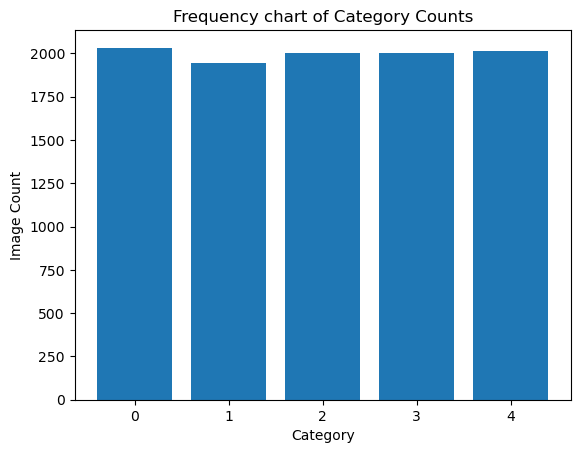

In [8]:
# Generate the list of class labels
all_the_classes = [train_data[i, -1] for i in range(len(train_data))]  # Extract the class labels from train_data
array_the_classes = np.array(all_the_classes)  # Convert to numpy array

# Count the occurrences of each class using Counter
class_counts = Counter(array_the_classes)
print(class_counts)

# Create a bar chart of the class frequencies
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Category")
plt.ylabel("Image Count")
plt.title("Frequency chart of Category Counts")
plt.show()

## Normalizing Pixel Values

In this step, we normalize the pixel values of the images to a range between 0 and 1 by dividing the raw pixel values by 255.0. This helps improve the performance of machine learning models by ensuring that the input values are on a similar scale.


In [9]:
# Normalize pixel values
X_train_full, X_test = X_train_full / 255.0, X_test / 255.0

In [10]:
# Print the first row of normalized images
print("First row of normalized images (pixel values):")
print(X_train_full[0])  


First row of normalized images (pixel values):
[0.         0.         0.         0.         0.         0.01176471
 0.         0.         0.         0.16078431 0.36078431 0.6745098
 0.39215686 0.09019608 0.08627451 0.12941176 0.40784314 0.53333333
 0.36470588 0.17254902 0.         0.         0.         0.00784314
 0.         0.         0.         0.         0.         0.
 0.         0.         0.00784314 0.         0.02352941 0.46666667
 0.65098039 0.69411765 0.62352941 0.6        0.89019608 0.90980392
 0.84313725 0.94117647 0.89019608 0.61176471 0.63529412 0.70588235
 0.68627451 0.4        0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.00784314
 0.         0.0627451  0.65098039 0.56078431 0.52156863 0.49411765
 0.5254902  0.4745098  0.4        0.57254902 0.67058824 0.62745098
 0.41568627 0.44313725 0.50980392 0.50980392 0.53333333 0.59215686
 0.62352941 0.         0.         0.00392157 0.         0.
 0.         0.         0.         0.0039

In [11]:
def separate_image_class(data_point_number):
    combined_array = train_data[data_point_number]  # Use train_data
    array_of_the_image = combined_array[:-1]  # Extract the pixel values
    classification_of_the_image = combined_array[-1]  # Extract the label
    class_of_the_image = tell_class(classification_of_the_image)
    return array_of_the_image, class_of_the_image


In [12]:
# Count the occurrences of each class using Counter
class_counts = Counter(array_the_classes)

# Normalize counts to get probabilities in a single line
total_count = sum(class_counts.values())  # Total number of images
probabilities = [count / total_count for count in class_counts.values()]  # Directly use the counts

print("Probabilities for each class:", probabilities)

Probabilities for each class: [0.2033, 0.1947, 0.2005, 0.2014, 0.2001]


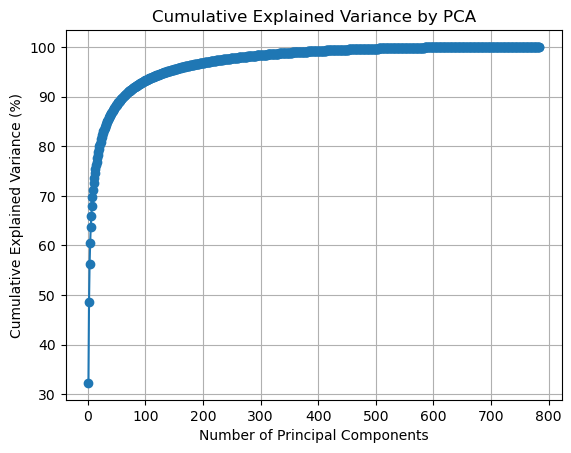

In [13]:
# Perform PCA
pca = PCA()
pca.fit(X_train_full)  # Use X_train_full or the variable containing your feature data

# Extract eigenvalues, eigenvectors, and explained variance ratio
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
explained_variance_ratio = pca.explained_variance_ratio_ * 100

# Plot cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance by PCA')
plt.grid()
plt.show()

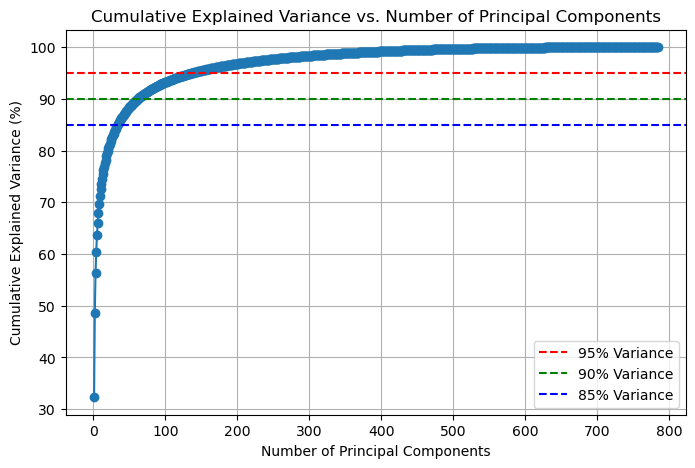

In [14]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=95, color='r', linestyle='--', label='95% Variance')
plt.axhline(y=90, color='g', linestyle='--', label='90% Variance')
plt.axhline(y=85, color='b', linestyle='--', label='85% Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Determine the number of components for different variance thresholds
thresholds = [95, 90, 85]
for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Number of components explaining {threshold}% variance: {n_components}")
    
# Data Transformation (Projection into Principal Component Space)
scores = pca.transform(X_train_full)  # Project the data into the principal component space
print("Shape of the transformed data:", scores.shape)  # Check the shape of the transformed data


Number of components explaining 95% variance: 137
Number of components explaining 90% variance: 62
Number of components explaining 85% variance: 34
Shape of the transformed data: (10000, 784)


In [16]:
n_components_90 = np.argmax(cumulative_variance >= 90) + 1

# Apply PCA with 90% variance threshold
pca_with_threshold = PCA(n_components=n_components_90)
transformed_images = pca_with_threshold.fit_transform(X_train_full)

print("Shape of the transformed images:", transformed_images.shape)

Shape of the transformed images: (10000, 62)


In [25]:
# Ensure the 'data/post_pca_subsets' folder exists
output_folder = 'data/post_pca_subsets'
os.makedirs(output_folder, exist_ok=True)

# Perform train-validation split
X_train, X_validate, Y_train, Y_validate = train_test_split(
    transformed_images, 
    array_the_classes, 
    test_size=0.2, 
    random_state=43, 
    stratify=array_the_classes
)

# Save the post-PCA subsets to the 'data/post_pca_subsets' folder
np.save(os.path.join(output_folder, 'X_train.npy'), X_train)
np.save(os.path.join(output_folder, 'X_validate.npy'), X_validate)
np.save(os.path.join(output_folder, 'Y_train.npy'), Y_train)
np.save(os.path.join(output_folder, 'Y_validate.npy'), Y_validate)

# PCA Image Reconstruction Analysis

## Observations
1. **Original Image**:
   - The original image is a clear and detailed grayscale image of a shirt.

2. **Reconstructed Image with 95% Variance**:
   - The image closely resembles the original, with minimal loss of detail.
   - This reconstruction uses **137 components**, retaining nearly all the important features.

3. **Reconstructed Image with 90% Variance**:
   - The image is slightly blurred compared to the 95% reconstruction but still retains the overall shape and key details.
   - This reconstruction uses **62 components**, striking a balance between dimensionality reduction and information retention.

4. **Reconstructed Image with 85% Variance**:
   - The image appears more blurred, with noticeable loss of finer details.
   - Despite the blurring, the overall shape of the shirt is still recognizable.
   - This reconstruction uses only **34 components**, achieving significant dimensionality reduction.

## Key Insights
- As the number of components decreases, the reconstructed images lose detail and become more blurred.
- Even with only **34 components** (85% variance), the image is still recognizable, indicating that PCA effectively compresses the data while preserving critical information.
- Retaining **90% variance** (62 components) offers a good trade-off between dimensionality reduction and maintaining important features for classification.
- Retaining **95% variance** (137 components) ensures minimal information loss but may not yield significantly better results compared to 90% in terms of classification performance.

## Recommendation
- For practical purposes, retaining **90% variance** appears to be the optimal choice, offering a significant reduction in dimensionality with minimal loss of detail.
- Retaining **85% variance** might be suitable in scenarios where computational efficiency is more critical than retaining fine details.

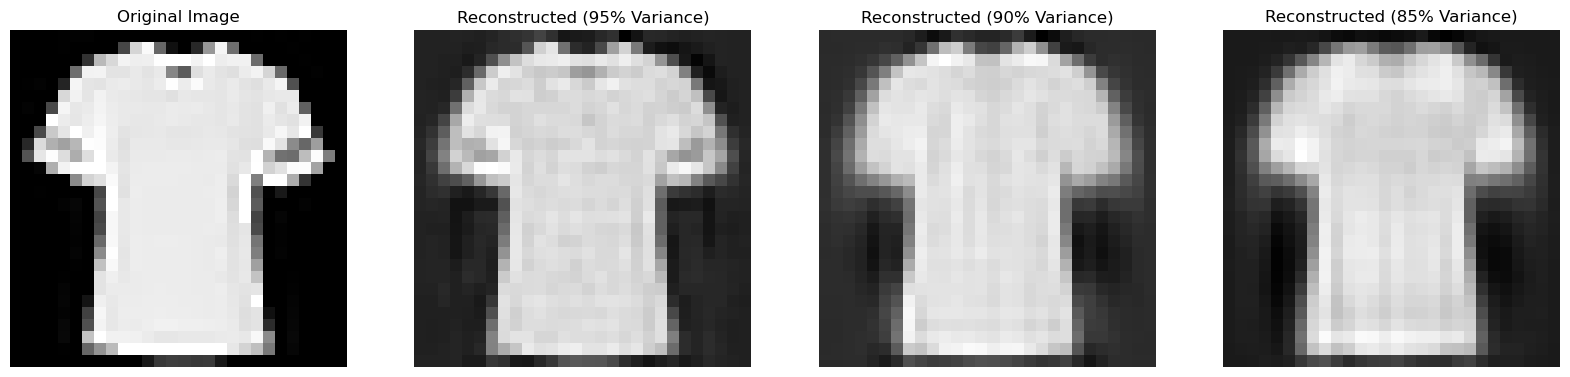

In [18]:
# Determine the number of components for 95%, 90%, and 85% variance
n_components_95 = np.argmax(cumulative_variance >= 95) + 1
n_components_90 = np.argmax(cumulative_variance >= 90) + 1
n_components_85 = np.argmax(cumulative_variance >= 85) + 1

# List of components and titles for plotting
components_and_titles = [
    (n_components_95, "95% Variance"),
    (n_components_90, "90% Variance"),
    (n_components_85, "85% Variance")
]

# Choose a sample image index
sample_index = 1  # Example index

# Plot original and reconstructed images in one row
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original image
axes[0].imshow(X_test[sample_index].reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Reconstructed images for different variance thresholds
for i, (n_components, title) in enumerate(components_and_titles):
    pca = PCA(n_components=n_components)
    X_test_pca = pca.fit_transform(X_test)
    reconstructed_image = pca.inverse_transform(X_test_pca[sample_index]).reshape(28, 28)
    
    axes[i + 1].imshow(reconstructed_image, cmap='gray')
    axes[i + 1].set_title(f"Reconstructed ({title})")
    axes[i + 1].axis('off')

plt.show()

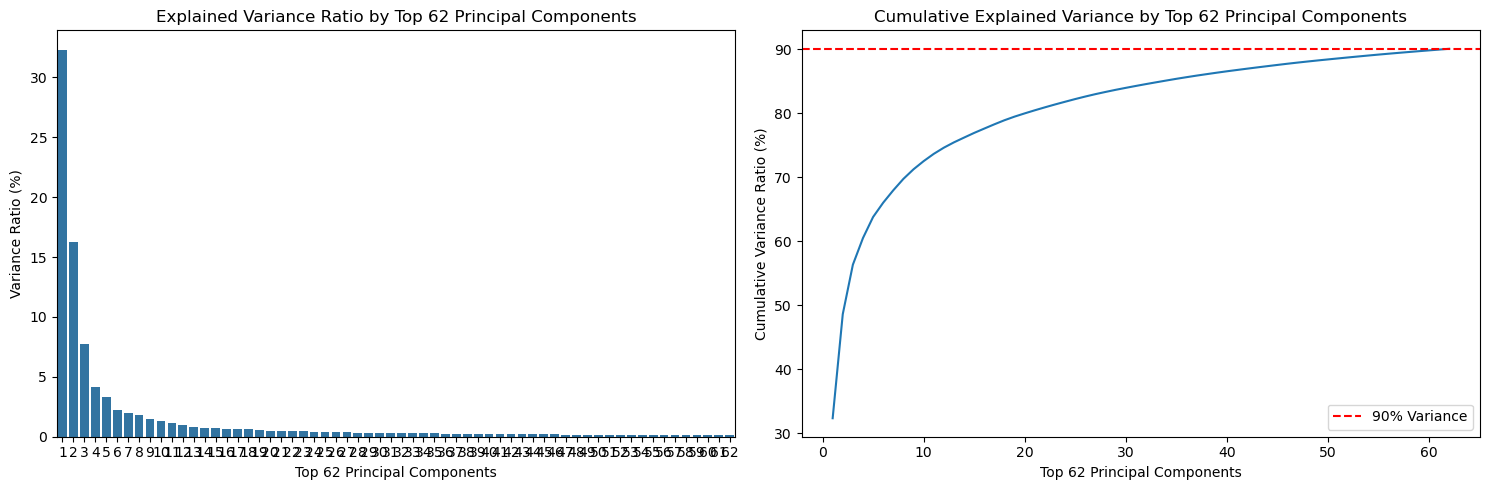

In [19]:
# Step 1: Extract the explained variance ratio for the top 62 PCs
top_62_explained_variance_ratio = explained_variance_ratio[:62]

# Step 2: Compute cumulative variance for top 62 PCs
cumulative_variance_top62 = np.cumsum(top_62_explained_variance_ratio)


# Step 3: Plot the explained variance ratio and cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Explained Variance Ratio for Top 62 PCs
sns.barplot(x=range(1, 63), y=top_62_explained_variance_ratio, ax=axes[0])
axes[0].set_title('Explained Variance Ratio by Top 62 Principal Components')
axes[0].set_xlabel('Top 62 Principal Components')
axes[0].set_ylabel('Variance Ratio (%)')

# Cumulative Explained Variance for Top 62 PCs
sns.lineplot(x=range(1, 63), y=cumulative_variance_top62, ax=axes[1])
axes[1].set_title('Cumulative Explained Variance by Top 62 Principal Components')
axes[1].set_xlabel('Top 62 Principal Components')
axes[1].set_ylabel('Cumulative Variance Ratio (%)')
axes[1].axhline(y=90, color='r', linestyle='--', label='90% Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# Step 1: Fit PCA with 62 components (maximum possible for this dataset)
pca62 = PCA(n_components=62)
pca62.fit(X_train)

# Step 2: Analyze the 62nd principal component (eigenvector)
pca_specified = pca62.components_[61]  # Extract the 62nd principal component (index 61)

# Find the pixel (feature) with the highest magnitude in this PC
most = np.argmax(np.abs(pca_specified))  # Index of the most influential feature (pixel)

# Convert the 1D index into 2D row and column indices for a 28x28 image
row, col = divmod(most, 28)

# Display the position of the most important pixel for this component
print(f"The most important pixel for the 62nd PC is at row {row}, column {col}, index {most}")


The most important pixel for the 62nd PC is at row 2, column 5, index 61


In [21]:
# Define a function to determine the number of components for a given variance threshold
def number_of_components(variance_threshold, explained_variance_ratio=explained_variance_ratio, eigenvalues=eigenvalues):
    ''' Determine how many principal components are needed to explain the given variance threshold (%) '''
    
    cum_explained_variance = 0
    no_of_components = 0
    array_of_features = []

    while cum_explained_variance <= variance_threshold:
        cum_explained_variance += explained_variance_ratio[no_of_components]
        no_of_components += 1

    # Collect eigenvalues for selected components
    for component in range(no_of_components):
        array_of_features.append(eigenvalues[component])

    return len(array_of_features)

In [22]:
# First, determine the number of components for the 90% variance threshold
n_components_90 = number_of_components(90)

# Apply PCA with the determined number of components
pca_with_threshold = PCA(n_components=n_components_90)
transformed_images = pca_with_threshold.fit_transform(X_train_full)  # Assuming X_train_full is defined

print("Shape of the transformed images:", transformed_images.shape)

# Ensure the folder 'data' exists, create it if it doesn't
output_folder = 'data'
os.makedirs(output_folder, exist_ok=True)  # This ensures the folder is created if it doesn't exist

# Save the PCA transformed data to the 'data' folder
output_file = os.path.join(output_folder, 'pca_transformed_images.npy')  # Path to save the file
np.save(output_file, transformed_images)  # Save to the file
print(f"PCA transformed data has been saved to '{output_file}'")

Shape of the transformed images: (10000, 62)
PCA transformed data has been saved to 'data/pca_transformed_images.npy'


In [26]:
# Perform train-validation-test split (20% validation, 20% test)
X_train, X_temp, Y_train, Y_temp = train_test_split(
    transformed_images, array_the_classes, test_size=0.4, random_state=43, stratify=array_the_classes
)

# Further split the temporary set into validation and test sets (50% each from 40% total)
X_validate, X_test, Y_validate, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=43, stratify=Y_temp
)

print(f"X_train shape: {X_train.shape}")
print(f"X_validate shape: {X_validate.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (6000, 62)
X_validate shape: (2000, 62)
X_test shape: (2000, 62)


In [27]:
# Ensure the 'data/post_pca_subsets' folder exists
output_folder = 'data/post_pca_subsets'
os.makedirs(output_folder, exist_ok=True)

# Save the new post-PCA subsets
np.save(os.path.join(output_folder, 'X_train.npy'), X_train)
np.save(os.path.join(output_folder, 'Y_train.npy'), Y_train)
np.save(os.path.join(output_folder, 'X_validate.npy'), X_validate)
np.save(os.path.join(output_folder, 'Y_validate.npy'), Y_validate)
np.save(os.path.join(output_folder, 'X_test.npy'), X_test)
np.save(os.path.join(output_folder, 'Y_test.npy'), Y_test)
